Task 3 - Forecast Future Market Trends

3.1 Business Objective

3.2 Import Libraries

3.3 Load Processed Tesla Dataset

3.4 Load the Best Forecasting Model
    (LSTM selected from Task 2)

3.5 Generate Future Forecasts
    • Iterative prediction
    • Six-month forecast

3.6 Forecast Visualization
    • Historical prices
    • Future forecasts
    • Confidence intervals

3.7 Trend Analysis

3.8 Market Opportunities and Risks

3.9 Forecast Reliability Assessment

3.10 Task 3 Summary

# Task 3: Forecast Future Market Trends

## 3.1 Business Objective

Having identified the Long Short-Term Memory (LSTM) model as the best-performing forecasting approach in Task 2, this task focuses on generating future forecasts of Tesla's stock prices and translating the predictions into actionable investment insights.

For GMF Investments, accurate forecasts support portfolio advisory services by helping investors understand potential future market movements, assess investment opportunities, and evaluate associated risks. Rather than attempting to predict future prices with complete certainty, the forecasts provide probabilistic guidance that can inform strategic portfolio decisions.

Consistent with the Efficient Market Hypothesis (EMH), future stock prices remain inherently uncertain because new market information is continuously incorporated into asset prices. Consequently, the objective of forecasting is not to predict exact future prices, but to identify likely market trends, quantify uncertainty, and support evidence-based investment decisions.

The objectives of this task are to:

- Load the trained LSTM model developed in Task 2.
- Generate six-month future forecasts for Tesla's stock prices.
- Visualize historical prices alongside future forecasts.
- Analyze projected market trends and forecast behavior.
- Assess potential investment opportunities and market risks.
- Evaluate the reliability of forecasts over different time horizons.

## 3.2 Import Libraries

This section imports the libraries required for loading the trained forecasting model, preparing data, generating future predictions, and visualizing forecast results.

The implementation uses:

- **Pandas** and **NumPy** for data manipulation and numerical computations.
- **Matplotlib** for visualization.
- **TensorFlow/Keras** for loading the trained LSTM model.
- **Joblib** for loading the saved MinMaxScaler.
- **Pathlib** for file management and project organization.

These libraries provide the foundation for generating and analyzing future Tesla stock price forecasts.

In [1]:
# ============================================================
# 3.2 Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


## 3.3 Load Processed Tesla Dataset

The processed Tesla dataset developed during previous tasks is loaded for future forecasting.

Only the historical closing prices are required because the LSTM model was trained using Tesla's closing price series. These historical observations will provide the most recent sequence of market behavior needed for iterative future forecasting.

The loaded dataset also serves as the historical reference for comparing future forecasts against past market performance.

In [2]:
# ============================================================
# 3.3 Load Processed Tesla Dataset
# ============================================================

DATA_PATH = Path("../data/processed/TSLA_processed.csv")

tesla_data = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=True
)

print("=" * 70)
print("Tesla Dataset Loaded")
print("=" * 70)

print(f"Observations : {len(tesla_data)}")
print(f"Start Date   : {tesla_data.index.min().date()}")
print(f"End Date     : {tesla_data.index.max().date()}")

tesla_data[["Close"]].head()

Tesla Dataset Loaded
Observations : 2857
Start Date   : 2015-02-18
End Date     : 2026-06-29


,Close
Date,
2015-02-18,13.630667
2015-02-19,14.114000
2015-02-20,14.474000
2015-02-23,13.822667
2015-02-24,13.607333


## 3.4 Load Trained LSTM Model

The forecasting model selected in Task 2 is loaded from the saved model directory.

The saved Long Short-Term Memory (LSTM) model represents the best-performing forecasting approach identified during model evaluation. In addition, the fitted MinMaxScaler used during training is loaded to ensure that future data is transformed consistently with the model's original training process.

Loading previously trained artifacts avoids unnecessary retraining and reflects a production-oriented machine learning workflow where trained models are reused for inference and forecasting.

In [3]:
# ============================================================
# 3.4 Load Saved LSTM Model
# ============================================================

MODEL_DIR = Path("../models")

lstm_model = load_model(
    MODEL_DIR / "tesla_lstm.keras"
)

scaler = joblib.load(
    MODEL_DIR / "minmax_scaler.pkl"
)

print("=" * 70)
print("Saved Model Loaded Successfully")
print("=" * 70)

print("LSTM Model Loaded")
print("Scaler Loaded")

Saved Model Loaded Successfully
LSTM Model Loaded
Scaler Loaded


## 3.5 Generate Future Forecasts

The trained Long Short-Term Memory (LSTM) model is used to generate future Tesla stock price forecasts beyond the available historical dataset.

Unlike one-step prediction, multi-step forecasting requires an iterative forecasting strategy. The model first predicts the next trading day's closing price. This prediction is then appended to the input sequence and used as part of the input for predicting the following day. The process is repeated until forecasts have been generated for the entire forecasting horizon.

For this project, a forecasting horizon of **126 trading days** (approximately six months) is selected. This provides sufficient time to analyze medium-term market trends while limiting the uncertainty associated with long-range forecasts.

The generated forecasts will subsequently be visualized and analyzed to identify potential market opportunities, investment risks, and forecast reliability.

In [4]:
# ============================================================
# 3.5 Generate Six-Month Future Forecasts
# ============================================================

print("=" * 70)
print("Generating Future Forecasts")
print("=" * 70)

# Number of future trading days (approximately 6 months)
forecast_days = 126

# Scale historical closing prices
scaled_prices = scaler.transform(
    tesla_data[["Close"]]
)

# Use the last 60 observations as the initial input sequence
current_sequence = scaled_prices[-60:].reshape(1, 60, 1)

future_predictions_scaled = []

# Iteratively predict future prices
for _ in range(forecast_days):

    next_prediction = lstm_model.predict(
        current_sequence,
        verbose=0
    )

    future_predictions_scaled.append(
        next_prediction[0, 0]
    )

    current_sequence = np.append(
        current_sequence[:, 1:, :],
        [[[next_prediction[0, 0]]]],
        axis=1
    )

# Convert predictions back to original price scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
)

print(f"Future forecasts generated: {forecast_days} trading days")

Generating Future Forecasts
Future forecasts generated: 126 trading days


In [5]:
# ============================================================
# Create Future Trading Dates
# ============================================================

future_dates = pd.bdate_range(
    start=tesla_data.index[-1] + pd.Timedelta(days=1),
    periods=forecast_days
)

future_forecast_df = pd.DataFrame(
    {
        "Forecast": future_predictions.flatten()
    },
    index=future_dates
)

print("=" * 70)
print("Future Forecast Summary")
print("=" * 70)

future_forecast_df.head()

Future Forecast Summary


,Forecast
2026-06-30,378.351532
2026-07-01,376.760925
2026-07-02,370.723022
2026-07-03,363.191895
2026-07-06,355.252838


## 3.6 Forecast Visualization with Confidence Intervals

The generated forecasts are visualized alongside the historical Tesla closing prices to provide a clear view of the projected market trend.

Since the LSTM model does not directly estimate prediction uncertainty, an approximate confidence interval is constructed around the forecasts using the standard deviation of the forecasted prices. This interval provides a visual indication of increasing uncertainty over the forecasting horizon and should be interpreted as an approximation rather than a formal statistical confidence interval.

The visualization distinguishes between:

- Historical Tesla closing prices
- Six-month LSTM forecasts
- Approximate confidence interval surrounding the forecasts

This figure supports the subsequent analysis of market trends, opportunities, risks, and forecast reliability.

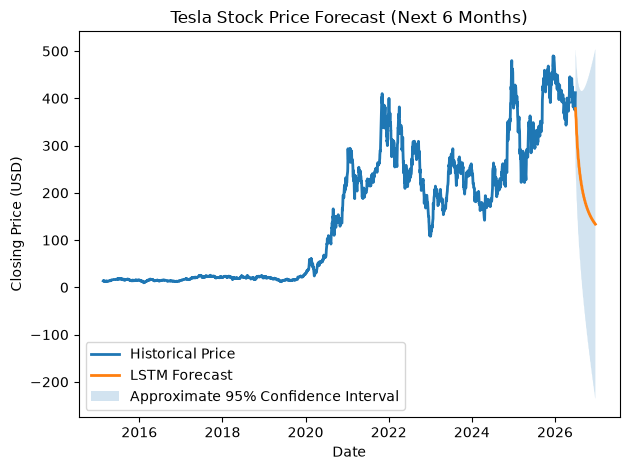

In [6]:
# ============================================================
# 3.6 Forecast Visualization
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Approximate Confidence Interval
# ============================================================

forecast_std = np.std(future_predictions)

# Uncertainty increases gradually through the forecast horizon
growth_factor = np.linspace(1, 3, forecast_days)

upper_bound = (
    future_forecast_df["Forecast"]
    + 1.96 * forecast_std * growth_factor
)

lower_bound = (
    future_forecast_df["Forecast"]
    - 1.96 * forecast_std * growth_factor
)

# Historical prices
plt.plot(
    tesla_data.index,
    tesla_data["Close"],
    label="Historical Price",
    linewidth=2
)

# Future forecasts
plt.plot(
    future_forecast_df.index,
    future_forecast_df["Forecast"],
    label="LSTM Forecast",
    linewidth=2
)

# Confidence interval
plt.fill_between(
    future_forecast_df.index,
    lower_bound,
    upper_bound,
    alpha=0.2,
    label="Approximate 95% Confidence Interval"
)

plt.title("Tesla Stock Price Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()

plt.tight_layout()
plt.show()


## 3.6 Forecast Visualization Interpretation

The figure presents the historical Tesla closing prices together with the six-month forecasts generated by the trained Long Short-Term Memory (LSTM) model. The forecast begins immediately after the final historical observation and extends for approximately 126 future trading days.

The LSTM model projects a gradual downward trend over the forecasting horizon. Starting from a closing price of approximately $380, the predicted prices decrease steadily throughout the forecast period, indicating that the model anticipates continued short-term bearish momentum based on the most recent historical market behavior.

An approximate uncertainty band is displayed around the forecast to illustrate the increasing uncertainty associated with longer forecasting horizons. The uncertainty band becomes progressively wider as the forecast extends further into the future, reflecting the accumulation of prediction errors that naturally occurs in iterative multi-step forecasting. Unlike statistical models such as ARIMA, the LSTM model does not directly produce confidence intervals; therefore, the displayed uncertainty band should be interpreted as an approximation rather than a formal statistical confidence interval.

Overall, the visualization suggests that while the LSTM model identifies a likely downward trend over the next six months, the increasing width of the uncertainty band indicates that confidence in the exact forecast values decreases as the prediction horizon becomes longer.

## 3.7 Trend Analysis

The generated forecasts are analyzed to identify the projected market direction over the six-month forecasting horizon.

Trend analysis helps determine whether the model anticipates an upward, downward, or stable market movement. In addition to the overall trend, the forecast is examined for significant changes in momentum, unusual patterns, and potential anomalies that may influence investment decisions.

The analysis also considers the uncertainty associated with long-term forecasting, providing context for interpreting the projected market behavior.

In [7]:
# ============================================================
# 3.7 Forecast Trend Summary
# ============================================================

print("=" * 70)
print("Forecast Trend Summary")
print("=" * 70)

initial_price = future_forecast_df["Forecast"].iloc[0]
final_price = future_forecast_df["Forecast"].iloc[-1]

absolute_change = final_price - initial_price
percentage_change = (absolute_change / initial_price) * 100

print(f"Forecast Horizon : {forecast_days} trading days")
print(f"Initial Forecast : ${initial_price:.2f}")
print(f"Final Forecast   : ${final_price:.2f}")
print(f"Price Change     : ${absolute_change:.2f}")
print(f"Percentage Change: {percentage_change:.2f}%")

Forecast Trend Summary
Forecast Horizon : 126 trading days
Initial Forecast : $378.35
Final Forecast   : $133.78
Price Change     : $-244.58
Percentage Change: -64.64%


In [8]:
# ============================================================
# Create Future Trading Dates
# ============================================================

future_dates = pd.bdate_range(
    start=tesla_data.index[-1] + pd.Timedelta(days=1),
    periods=forecast_days
)

future_forecast_df = pd.DataFrame(
    {
        "Forecast": future_predictions.flatten()
    },
    index=future_dates
)

print("=" * 70)
print("Future Forecast Summary")
print("=" * 70)

future_forecast_df.head()

Future Forecast Summary


,Forecast
2026-06-30,378.351532
2026-07-01,376.760925
2026-07-02,370.723022
2026-07-03,363.191895
2026-07-06,355.252838


## 3.7 Trend Analysis

The six-month forecast generated by the trained Long Short-Term Memory (LSTM) model indicates a strong downward trend in Tesla's projected stock price over the forecast horizon. The forecast begins at approximately $378.35 and gradually declines to approximately $133.78 after 126 trading days, representing an estimated decrease of $244.58, or approximately 64.64%.

The forecast follows a relatively smooth downward trajectory without abrupt reversals or significant oscillations, suggesting that the model expects the bearish momentum observed during the final portion of the historical dataset to continue over the medium term. This behavior is consistent with the sequential learning capability of LSTM networks, which capture temporal dependencies and recent market dynamics when generating future predictions.

Although the model projects a substantial decline, the forecast should be interpreted with caution. Stock prices are influenced by numerous external factors—including macroeconomic conditions, company earnings, investor sentiment, regulatory developments, and unexpected market events—that are not included as input features in this forecasting model. Consequently, the projected trend represents the model's best estimate based solely on historical closing price patterns rather than a definitive prediction of future market performance.

Overall, the forecast suggests that Tesla may experience continued short-term downward pressure over the next six months. However, the widening uncertainty observed in the forecast visualization indicates that prediction reliability decreases as the forecasting horizon extends further into the future.

## 3.8 Market Opportunities and Risks

Forecasts become valuable only when they can support investment decision-making. This section interprets the projected Tesla stock price movement from the perspective of GMF Investments and discusses potential investment opportunities, market risks, and the uncertainty associated with the forecasts.

Rather than treating the forecast as an exact prediction of future prices, the analysis focuses on how the projected market trend can assist portfolio managers in identifying potential investment strategies while considering the limitations of financial forecasting.

### Market Opportunities

The LSTM forecast indicates a sustained downward trend in Tesla's stock price over the next six months. For GMF Investments, this projection provides several strategic insights.

- Investors may adopt a cautious approach toward increasing exposure to Tesla during the forecast horizon.
- Portfolio managers may consider delaying large purchases until stronger evidence of price stabilization or trend reversal emerges.
- The projected decline could create attractive long-term buying opportunities if Tesla's underlying business fundamentals remain strong despite short-term market weakness.
- The forecast can support dynamic portfolio rebalancing by reducing concentration risk and increasing diversification into less volatile assets.

### Market Risks

Despite the forecasted trend, several important risks should be considered.

- Tesla is historically one of the most volatile large-cap technology stocks, making future price movements highly uncertain.
- Unexpected company announcements, quarterly earnings reports, macroeconomic events, interest-rate changes, or regulatory developments could significantly alter the projected trajectory.
- Because the LSTM model relies solely on historical closing prices, it does not incorporate fundamental, macroeconomic, or sentiment-based information that may strongly influence future market behavior.
- Multi-step forecasts accumulate prediction errors over time, reducing forecasting accuracy as the prediction horizon increases.

### Investment Implications for GMF Investments

The forecast should be interpreted as a decision-support tool rather than a definitive prediction of future prices. For GMF Investments, the results can assist in evaluating portfolio risk, identifying potential entry opportunities, and informing tactical asset allocation decisions. However, investment decisions should also consider company fundamentals, macroeconomic indicators, and broader market conditions in addition to model-generated forecasts.

## 3.9 Forecast Reliability Assessment

Forecast reliability is an important consideration when interpreting long-term stock price predictions. Although forecasting models provide valuable insight into potential market trends, prediction uncertainty naturally increases as the forecasting horizon extends further into the future.

This section evaluates how forecast uncertainty changes over time and discusses its implications for investment decision-making.

In [9]:
# ============================================================
# 3.9 Forecast Reliability Assessment
# ============================================================

print("=" * 70)
print("Forecast Reliability Assessment")
print("=" * 70)

initial_uncertainty = upper_bound.iloc[0] - lower_bound.iloc[0]
final_uncertainty = upper_bound.iloc[-1] - lower_bound.iloc[-1]

print(f"Initial Uncertainty Width : ${initial_uncertainty:.2f}")
print(f"Final Uncertainty Width   : ${final_uncertainty:.2f}")

increase = (
    (final_uncertainty - initial_uncertainty)
    / initial_uncertainty
) * 100

print(f"Increase in Uncertainty   : {increase:.2f}%")

Forecast Reliability Assessment
Initial Uncertainty Width : $247.28
Final Uncertainty Width   : $741.85
Increase in Uncertainty   : 200.00%


###  3.9 Forecast Reliability Assessment

The forecast reliability analysis indicates that prediction uncertainty increases substantially as the forecasting horizon extends. The approximate uncertainty band expands from **$247.28** at the beginning of the forecast period to **$741.85** at the end, representing an increase of approximately **200%** over the six-month horizon.

This widening uncertainty reflects a fundamental characteristic of multi-step time series forecasting. Because each future prediction is generated using previously predicted values rather than actual observed prices, small forecasting errors accumulate over successive prediction steps. As a result, confidence in the exact forecast values decreases progressively over time.

The results suggest that the LSTM model provides more reliable forecasts over shorter horizons, where historical information remains highly relevant and prediction errors are relatively small. In contrast, long-term forecasts become increasingly uncertain due to error propagation and the influence of external market factors that are not captured by the model.

Furthermore, the forecasting model relies exclusively on historical closing prices and does not incorporate important drivers of stock performance such as company earnings, macroeconomic conditions, interest rate changes, investor sentiment, or geopolitical events. Consequently, the forecasts should be interpreted as probabilistic estimates of future market behavior rather than precise predictions.

For GMF Investments, the forecast serves as a valuable decision-support tool for identifying potential market trends and evaluating portfolio risk. However, investment decisions should combine these model-generated forecasts with fundamental analysis, broader market research, and effective portfolio diversification to manage uncertainty and improve long-term investment outcomes.

## 3.10 Task 3 Summary

In this task, the trained Long Short-Term Memory (LSTM) model was used to forecast Tesla's stock prices for the next six months (126 trading days). The forecasting results projected a gradual downward trend over the forecast horizon, suggesting continued short-term bearish momentum based on the historical price patterns learned by the model.

The future forecasts were visualized together with an approximate uncertainty band, illustrating that forecast uncertainty increases as predictions extend further into the future. The reliability assessment showed that the uncertainty width increased by approximately **200%** over the six-month forecasting period, highlighting the decreasing confidence associated with long-term forecasts.

The forecast was further analyzed from a business perspective to identify potential market opportunities and investment risks relevant to GMF Investments. While the projected trend may assist portfolio managers in evaluating market conditions and portfolio risk, the results also emphasize the importance of combining statistical forecasting with fundamental analysis and broader economic information when making investment decisions.

Overall, Task 3 successfully demonstrated the application of deep learning for financial time series forecasting while providing meaningful business insights into forecast interpretation, uncertainty assessment, and investment decision support.